In [51]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


In [52]:

sales = pd.read_csv('data/sales.csv')
items = pd.read_csv('data/items.csv')

# 1. Data Type Conversion
sales['date'] = pd.to_datetime(sales['date'])

# 2. Merge Tables
# It is critical to do a left join on sales to keep every transaction
df = sales.merge(items, on='item_name', how='left')

df.head()

,date,time,item_name,transaction_type,own_cup,surcharge,customer_id,price,production_cost,item_type,drink_temperature,drink_type
0,2022-01-01,07:03:30,Cold Brew,Takeout,True,False,26946,4.75,1.35,Drink,Cold,Coffee
1,2022-01-01,07:30:58,Iced Coffee,Takeout,True,False,24356,4.00,1.10,Drink,Cold,Coffee
2,2022-01-01,08:32:23,Iced Latte,Takeout,False,False,3760,4.60,1.25,Drink,Cold,Coffee
3,2022-01-01,08:45:03,Latte,Dine-in,True,False,5900,4.50,1.20,Drink,Hot,Coffee
4,2022-01-01,09:03:47,Latte,Takeout,False,False,11589,4.50,1.20,Drink,Hot,Coffee


In [53]:
# Construction: Sept 4, 2022 - Dec 12, 2022 
# Rebrand/Surcharge Start: Nov 1, 2023 

conditions = [
    (df['date'] >= '2022-09-04') & (df['date'] <= '2022-12-12'),
    (df['date'] < '2023-11-01'),
    (df['date'] >= '2023-11-01')
]
choices = ['Construction', 'Pre-Rebrand', 'Post-Rebrand']

# Note: Any dates before Construction will be labeled 'Pre-Rebrand' by this logic,
# which is fine, but be aware of seasonality if you have data from early 2022.
df['period'] = np.select(conditions, choices, default='Other')

SURCHARGE_AMT = 0.50

df['surcharge_amt'] = np.where(df['surcharge'] == True, SURCHARGE_AMT, 0.0)
df['total_revenue'] = df['price'] + df['surcharge_amt']

# Case assumption: Production costs are constant [cite: 126]
df['profit'] = df['total_revenue'] - df['production_cost']
df.head()





,date,time,item_name,transaction_type,own_cup,surcharge,customer_id,price,production_cost,item_type,drink_temperature,drink_type,period,surcharge_amt,total_revenue,profit
0,2022-01-01,07:03:30,Cold Brew,Takeout,True,False,26946,4.75,1.35,Drink,Cold,Coffee,Pre-Rebrand,0.0,4.75,3.40
1,2022-01-01,07:30:58,Iced Coffee,Takeout,True,False,24356,4.00,1.10,Drink,Cold,Coffee,Pre-Rebrand,0.0,4.00,2.90
2,2022-01-01,08:32:23,Iced Latte,Takeout,False,False,3760,4.60,1.25,Drink,Cold,Coffee,Pre-Rebrand,0.0,4.60,3.35
3,2022-01-01,08:45:03,Latte,Dine-in,True,False,5900,4.50,1.20,Drink,Hot,Coffee,Pre-Rebrand,0.0,4.50,3.30
4,2022-01-01,09:03:47,Latte,Takeout,False,False,11589,4.50,1.20,Drink,Hot,Coffee,Pre-Rebrand,0.0,4.50,3.30


In [54]:
def calculate_kpis(data):
    # Filter for drinks only for cup metrics, as per case logic
    # own_cup is N/A for merch, so we can technically just use mean(),
    # but being explicit is safer.
    drinks_only = data[data['item_type'] == 'Drink']
    
    return pd.Series({
        # --- Financials ---
        'Total Revenue': data['total_revenue'].sum(),
        'Total Profit': data['profit'].sum(),
        'Profit Margin': (data['profit'].sum() / data['total_revenue'].sum()) * 100,
        'Avg Order Value': data['total_revenue'].mean(),
        
        # --- Volume ---
        'Total Transactions': len(data),
        'Daily Txn Avg': len(data) / data['date'].nunique(),
        
        # --- Behaviour (Sustainability) ---
        # Percentage of drinks where own_cup is True
        'Reusable Cup Rate (%)': drinks_only['own_cup'].mean() * 100,
        
        # Percentage of orders that are Dine-In
        'Dine-In Rate (%)': (data['transaction_type'] == 'Dine-in').mean() * 100,
        
        # --- Surcharge Impact ---
        'Total Surcharges Collected': data['surcharge_amt'].sum(),
        'Surcharged Txn Count': data['surcharge'].sum()
    })

# Group by Period and Apply
kpi_table = df.groupby('period').apply(calculate_kpis).transpose()

# Reorder columns to match chronological flow
cols = ['Construction', 'Pre-Rebrand', 'Post-Rebrand']
# Filter to ensure columns exist (in case your csv doesn't have construction dates)
existing_cols = [c for c in cols if c in kpi_table.columns]
kpi_table = kpi_table[existing_cols]

print(kpi_table)

period                      Construction   Pre-Rebrand  Post-Rebrand
Total Revenue               10086.600000  81390.600000  74890.900000
Total Profit                 7154.950000  57697.450000  52632.200000
Profit Margin                  70.935201     70.889574     70.278498
Avg Order Value                 4.849327      4.860882      5.434359
Total Transactions           2080.000000  16744.000000  13781.000000
Daily Txn Avg                  20.800000     29.427065     32.274005
Reusable Cup Rate (%)          38.756948     40.127868     48.674968
Dine-In Rate (%)               30.288462     30.584090     40.925912
Total Surcharges Collected      0.000000      0.000000   1726.000000
Surcharged Txn Count            0.000000      0.000000   3452.000000


/tmp/ipykernel_1404/1476901499.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  kpi_table = df.groupby('period').apply(calculate_kpis).transpose()


/tmp/ipykernel_1404/3783450809.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_financials = df.groupby('period').apply(


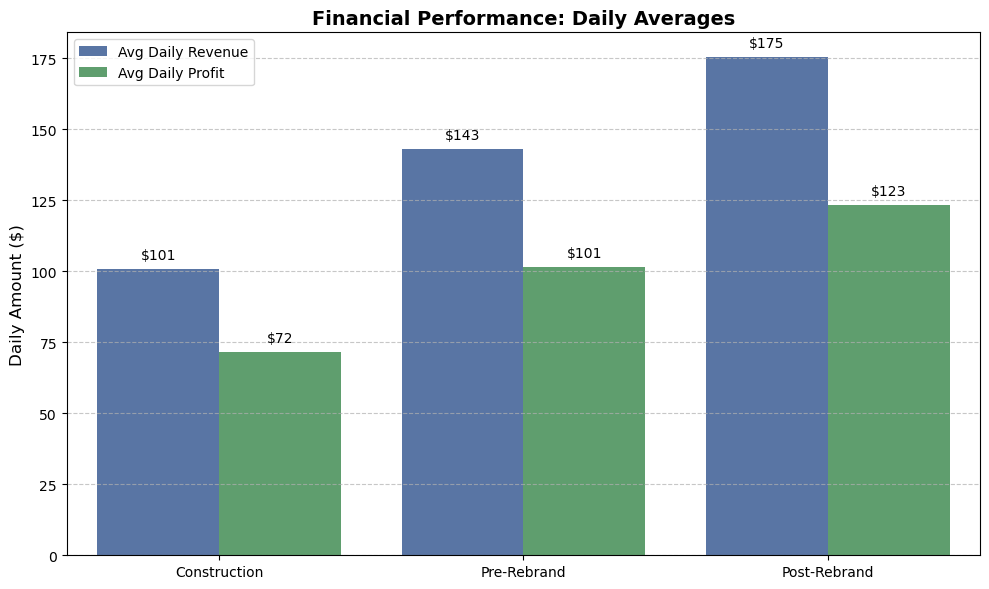

In [55]:

# 1. Prepare the Data for Plotting
# We need to reshape the data so Seaborn can read it easily.
# We are calculating DAILY averages to normalize for different time period lengths.

# Re-using the 'df' from the previous step to get raw daily stats
daily_financials = df.groupby('period').apply(
    lambda x: pd.Series({
        'Avg Daily Revenue': x['total_revenue'].sum() / x['date'].nunique(),
        'Avg Daily Profit': x['profit'].sum() / x['date'].nunique()
    })
).reset_index()

# Melt the dataframe to make it "long" for Seaborn (easy side-by-side plotting)
plot_data = daily_financials.melt(
    id_vars='period', 
    var_name='Metric', 
    value_name='Amount ($)'
)

# 2. Define Order of Periods (Chronological)
period_order = ['Construction', 'Pre-Rebrand', 'Post-Rebrand']

# 3. Create the Chart
plt.figure(figsize=(10, 6))

# Use a color palette that distinguishes Money In (Rev) vs Money Kept (Profit)
sns.barplot(
    data=plot_data, 
    x='period', 
    y='Amount ($)', 
    hue='Metric', 
    order=period_order,
    palette={'Avg Daily Revenue': '#4c72b0', 'Avg Daily Profit': '#55a868'}
)

# 4. Formatting for Impact
plt.title('Financial Performance: Daily Averages', fontsize=14, fontweight='bold')
plt.ylabel('Daily Amount ($)', fontsize=12)
plt.xlabel('')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title=None)

# Add value labels on top of bars for precision
for p in plt.gca().patches:
    if p.get_height() > 0: # Avoid labeling empty bars
        plt.gca().annotate(f'${p.get_height():.0f}', 
                           (p.get_x() + p.get_width() / 2., p.get_height()), 
                           ha='center', va='bottom', 
                           xytext=(0, 5), 
                           textcoords='offset points')

plt.tight_layout()
plt.show()

In [56]:
#Time and own-cup
# Convert date column to datetime
sales["date"] = pd.to_datetime(sales["date"], errors="coerce")

# Filter for dates AFTER 2023-11-01
filtered_sales = sales[sales["date"] > "2023-11-01"]

# Extract only the needed columns
surcharge_owncups = filtered_sales[["date", "surcharge", "own_cup"]].copy()

surcharge_owncups.head()


,date,surcharge,own_cup
18853,2023-11-02,False,True
18854,2023-11-02,False,True
18855,2023-11-02,False,False
18856,2023-11-02,True,False
18857,2023-11-02,False,NaN


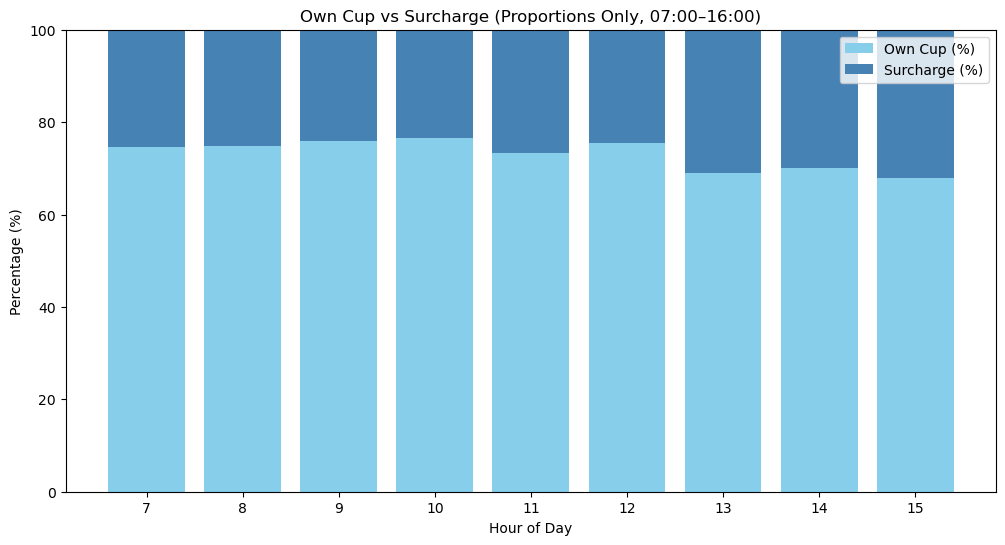

In [57]:
sales= sales.dropna()
# --- Convert date & time ---
sales["date"] = pd.to_datetime(sales["date"], errors="coerce")
sales["time"] = pd.to_datetime(sales["time"], format="%H:%M:%S", errors="coerce")

# --- Filter date range ---
filtered = sales[sales["date"] >= "2023-01-22"].copy()

# --- Extract hour (07–16 only) ---
filtered["hour"] = filtered["time"].dt.hour
filtered = filtered[(filtered["hour"] >= 7) & (filtered["hour"] <= 16)]

# --- Convert to proper booleans & drop missing ---
filtered["own_cup"] = filtered["own_cup"].replace("N/A", pd.NA).astype("boolean")
filtered["surcharge"] = filtered["surcharge"].replace("N/A", pd.NA).astype("boolean")

# Only keep rows where either value is TRUE
filtered = filtered[(filtered["own_cup"] == True) | (filtered["surcharge"] == True)]

# Drop rows where both values are missing
filtered = filtered.dropna(subset=["own_cup", "surcharge"], how="all")

# --- Count how many TRUE values per hour ---
hour_counts = filtered.groupby("hour").agg(
    own_cup_count=("own_cup", lambda x: (x == True).sum()),
    surcharge_count=("surcharge", lambda x: (x == True).sum())
).reset_index()

# --- Compute percentages of only these two categories ---
hour_counts["total"] = hour_counts["own_cup_count"] + hour_counts["surcharge_count"]
hour_counts["own_cup_pct"] = hour_counts["own_cup_count"] / hour_counts["total"] * 100
hour_counts["surcharge_pct"] = hour_counts["surcharge_count"] / hour_counts["total"] * 100

# --- Plot percentages ---
plt.figure(figsize=(12, 6))

plt.bar(hour_counts["hour"], hour_counts["own_cup_pct"],
        label="Own Cup (%)", color="skyblue")

plt.bar(hour_counts["hour"], hour_counts["surcharge_pct"],
        bottom=hour_counts["own_cup_pct"],
        label="Surcharge (%)", color="steelblue")

plt.xticks(hour_counts["hour"])
plt.xlabel("Hour of Day")
plt.ylabel("Percentage (%)")
plt.title("Own Cup vs Surcharge (Proportions Only, 07:00–16:00)")
plt.legend()

plt.ylim(0, 100)

plt.show()

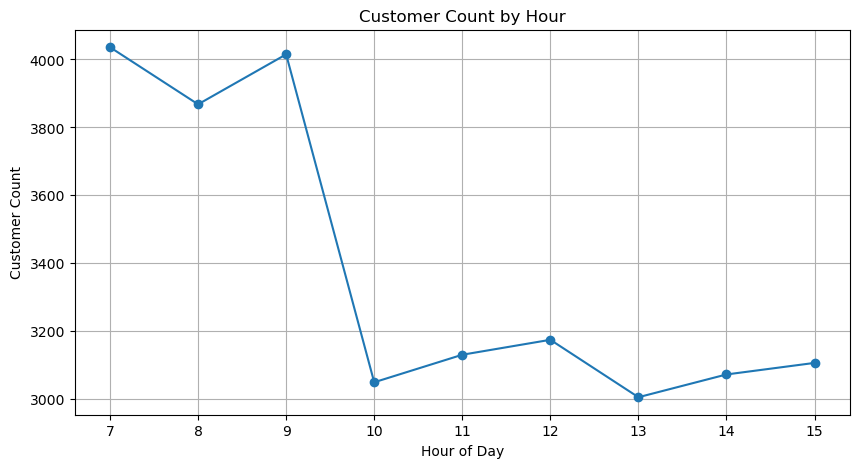

In [58]:
sales["time"] = pd.to_datetime(sales["time"], format="%H:%M:%S", errors="coerce")

sales["hour"] = sales["time"].dt.hour

hour_counts = sales.groupby("hour").size().reset_index(name="customer_count")

plt.figure(figsize=(10, 5))
plt.plot(hour_counts["hour"], hour_counts["customer_count"], marker='o')

plt.xlabel("Hour of Day")
plt.ylabel("Customer Count")
plt.title("Customer Count by Hour")
plt.xticks(hour_counts["hour"])  # Show all hours that appear
plt.grid(True)
plt.show()

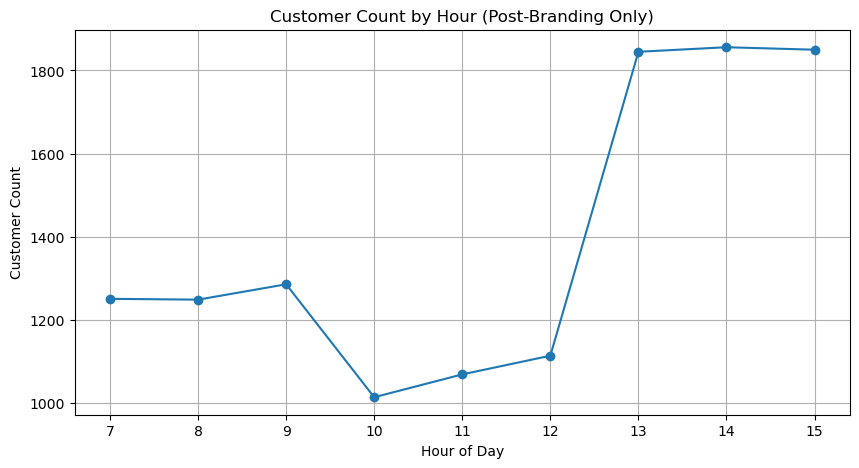

In [59]:
sales["date"] = pd.to_datetime(sales["date"], errors="coerce")
post_brand = sales[sales["date"] >= "2023-11-01"].copy()

# Convert time to datetime
post_brand["time"] = pd.to_datetime(post_brand["time"], format="%H:%M:%S", errors="coerce")

# Extract hour
post_brand["hour"] = post_brand["time"].dt.hour

# Count customers per hour (post-branding only)
hour_counts_post = (
    post_brand.groupby("hour")
    .size()
    .reset_index(name="customer_count")
)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(hour_counts_post["hour"], hour_counts_post["customer_count"], marker='o')

plt.xlabel("Hour of Day")
plt.ylabel("Customer Count")
plt.title("Customer Count by Hour (Post-Branding Only)")
plt.xticks(hour_counts_post["hour"])
plt.grid(True)
plt.show()

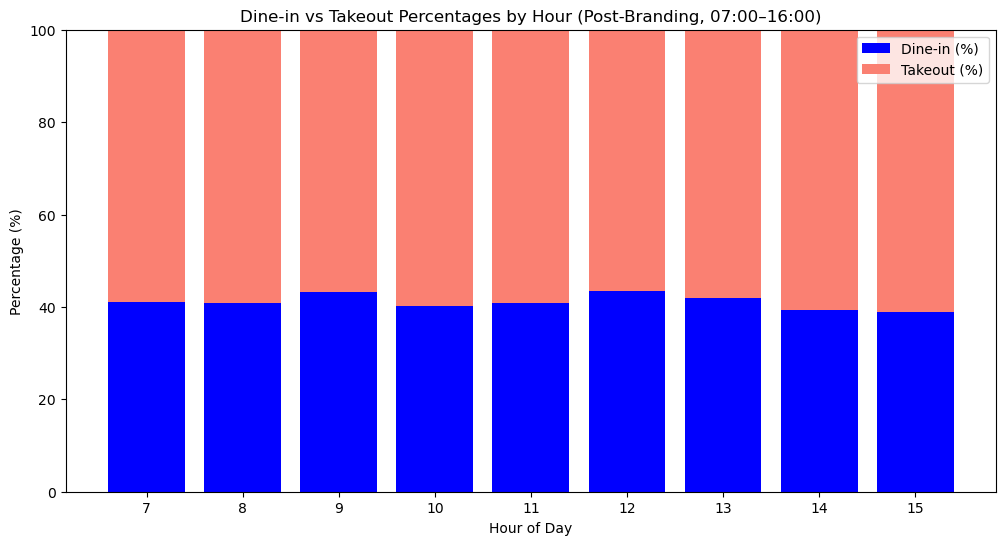

In [66]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert to datetime
sales["date"] = pd.to_datetime(sales["date"], errors="coerce")
sales["time"] = pd.to_datetime(sales["time"], format="%H:%M:%S", errors="coerce")

# FILTER FOR POST-BRANDING ONLY
post_brand = sales[sales["date"] >= "2023-11-01"].copy()

# Extract hour
post_brand["hour"] = post_brand["time"].dt.hour

# Keep 7AM–4PM only
filtered = post_brand[(post_brand["hour"] >= 7) & (post_brand["hour"] <= 16)].copy()

# Keep Dine-in and Takeout only
filtered = filtered[filtered["transaction_type"].isin(["Dine-in", "Takeout"])]

# Count by hour × type
hour_counts = filtered.groupby(["hour", "transaction_type"]).size().unstack(fill_value=0)

# Ensure both columns exist
if "Dine-in" not in hour_counts.columns:
    hour_counts["Dine-in"] = 0
if "Takeout" not in hour_counts.columns:
    hour_counts["Takeout"] = 0

# Compute percentages
hour_counts["total"] = hour_counts["Dine-in"] + hour_counts["Takeout"]
hour_counts["dine_pct"] = hour_counts["Dine-in"] / hour_counts["total"] * 100
hour_counts["takeout_pct"] = hour_counts["Takeout"] / hour_counts["total"] * 100

# Plot
plt.figure(figsize=(12, 6))

plt.bar(hour_counts.index, hour_counts["dine_pct"],
        label="Dine-in (%)", color="blue")

plt.bar(hour_counts.index, hour_counts["takeout_pct"],
        bottom=hour_counts["dine_pct"],
        label="Takeout (%)", color="salmon")

plt.xticks(hour_counts.index)
plt.xlabel("Hour of Day")
plt.ylabel("Percentage (%)")
plt.title("Dine-in vs Takeout Percentages by Hour (Post-Branding, 07:00–16:00)")
plt.legend()
plt.ylim(0, 100)

plt.show()


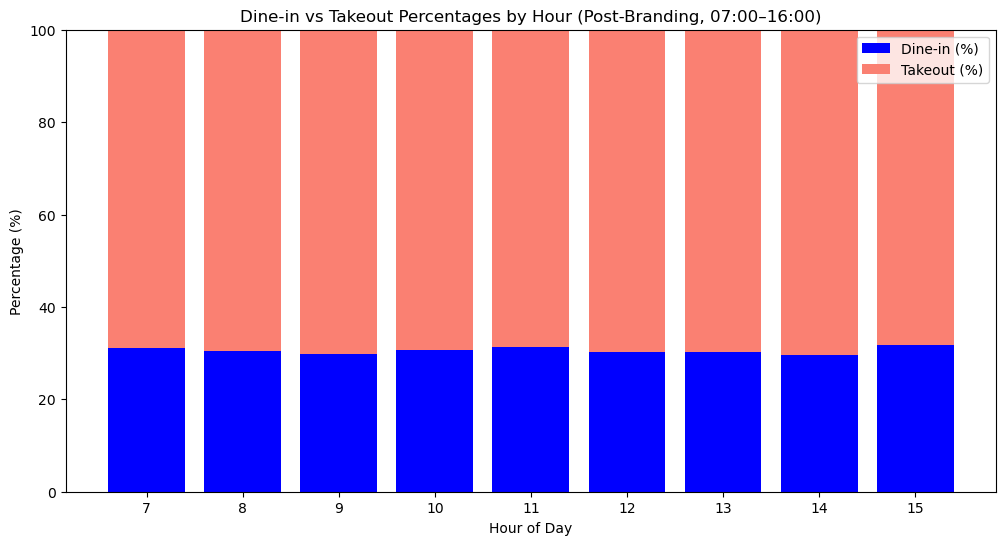

In [67]:
# Convert to datetime
sales["date"] = pd.to_datetime(sales["date"], errors="coerce")
sales["time"] = pd.to_datetime(sales["time"], format="%H:%M:%S", errors="coerce")

# FILTER FOR POST-BRANDING ONLY
post_brand = sales[sales["date"] <= "2023-11-01"].copy()

# Extract hour
post_brand["hour"] = post_brand["time"].dt.hour

# Keep 7AM–4PM only
filtered = post_brand[(post_brand["hour"] >= 7) & (post_brand["hour"] <= 16)].copy()

# Keep Dine-in and Takeout only
filtered = filtered[filtered["transaction_type"].isin(["Dine-in", "Takeout"])]

# Count by hour × type
hour_counts = filtered.groupby(["hour", "transaction_type"]).size().unstack(fill_value=0)

# Ensure both columns exist
if "Dine-in" not in hour_counts.columns:
    hour_counts["Dine-in"] = 0
if "Takeout" not in hour_counts.columns:
    hour_counts["Takeout"] = 0

# Compute percentages
hour_counts["total"] = hour_counts["Dine-in"] + hour_counts["Takeout"]
hour_counts["dine_pct"] = hour_counts["Dine-in"] / hour_counts["total"] * 100
hour_counts["takeout_pct"] = hour_counts["Takeout"] / hour_counts["total"] * 100

# Plot
plt.figure(figsize=(12, 6))

plt.bar(hour_counts.index, hour_counts["dine_pct"],
        label="Dine-in (%)", color="blue")

plt.bar(hour_counts.index, hour_counts["takeout_pct"],
        bottom=hour_counts["dine_pct"],
        label="Takeout (%)", color="salmon")

plt.xticks(hour_counts.index)
plt.xlabel("Hour of Day")
plt.ylabel("Percentage (%)")
plt.title("Dine-in vs Takeout Percentages by Hour (Post-Branding, 07:00–16:00)")
plt.legend()
plt.ylim(0, 100)

plt.show()

Percentage of Hot drinks among own-cup users: 79.2115775985528
Percentage of Cold drinks among own-cup users: 20.7884224014472


/tmp/ipykernel_1404/2288647489.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace(["N/A", "NaN"], pd.NA)   # adjust if your missing code is different


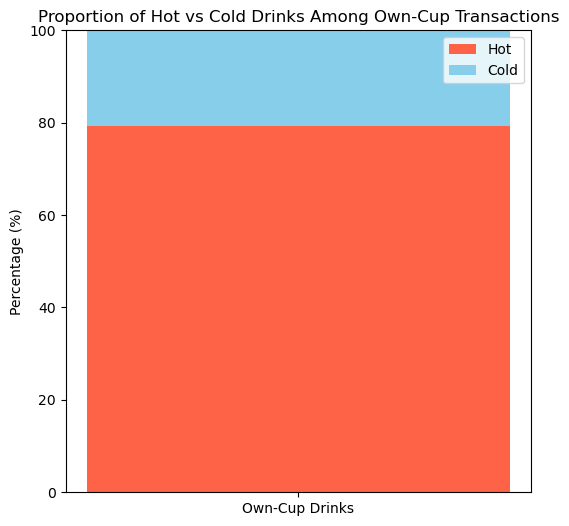

In [61]:
##Are customers less likely to bring their own cups for cold drinks vs hot? Why might that be?


#  MERGE DATASETS ON item_name
#    - Keep all rows from sales
#    - Bring in drink_temperature from items
# ============================================================
merged = pd.merge(
    sales,
    items[["item_name", "drink_temperature"]],  # only need this extra column
    on="item_name",
    how="left"
)
# CLEAN own_cup COLUMN
#    - Convert "N/A" (or similar) to missing values
#    - Cast to proper boolean type
# ============================================================
merged["own_cup"] = (
    merged["own_cup"]
    .replace(["N/A", "NaN"], pd.NA)   # adjust if your missing code is different
    .astype("boolean")
)

owncup_drinks = merged[merged["own_cup"] == True].copy()

# KEEP ONLY HOT / COLD DRINKS
#    - Drop any rows where drink_temperature is N/A or something else
owncup_drinks = owncup_drinks[
    owncup_drinks["drink_temperature"].isin(["Hot", "Cold"])
].copy()

#  CALCULATE PROPORTIONS OF HOT VS COLD AMONG OWN-CUP DRINKS
#    - value_counts(normalize=True) gives proportions (0–1)
#    - Multiply by 100 to get percentages
#    - Reindex to always have both "Hot" and "Cold" in fixed order
temp_counts = (
    owncup_drinks["drink_temperature"]
    .value_counts(normalize=True)
    .reindex(["Hot", "Cold"], fill_value=0)
    * 100
)

hot_pct = temp_counts["Hot"]
cold_pct = temp_counts["Cold"]

print("Percentage of Hot drinks among own-cup users:", hot_pct)
print("Percentage of Cold drinks among own-cup users:", cold_pct)

# PLOT STACKED BAR CHART
#    - Single bar representing all own-cup transactions
#    - Bottom segment: Hot drink percentage
#    - Top segment: Cold drink percentage
#    - Total height = 100%
plt.figure(figsize=(6, 6))

# Bottom part: Hot
plt.bar(["Own-Cup Drinks"], [hot_pct], label="Hot", color="tomato")

# Top part: Cold (stacked on top of Hot)
plt.bar(
    ["Own-Cup Drinks"],
    [cold_pct],
    bottom=[hot_pct],
    label="Cold",
    color="skyblue"
)

plt.ylabel("Percentage (%)")
plt.title("Proportion of Hot vs Cold Drinks Among Own-Cup Transactions")
plt.ylim(0, 100)
plt.legend()

plt.show()




Percentage Hot: 67.68655001477299
Percentage Cold: 32.31344998522701


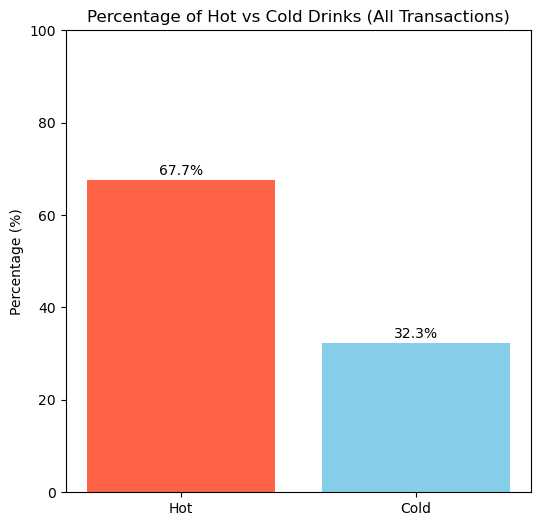

In [62]:
### Proportions of people buying hot and cold drinks:

merged = pd.merge(
    sales,
    items[["item_name", "drink_temperature"]],
    on="item_name",
    how="left"
)

merged = merged[merged["drink_temperature"].isin(["Hot", "Cold"])]

#CALCULATE PERCENTAGES OF HOT AND COLD DRINKS
temp_counts = (
    merged["drink_temperature"]
    .value_counts(normalize=True)
    .reindex(["Hot", "Cold"], fill_value=0) * 100
)

hot_pct = temp_counts["Hot"]
cold_pct = temp_counts["Cold"]

print("Percentage Hot:", hot_pct)
print("Percentage Cold:", cold_pct)


#PLOT BAR CHART (Non-stacked — clearer for comparison)
plt.figure(figsize=(6, 6))
plt.bar(["Hot"], [hot_pct], color="tomato", label="Hot")
plt.bar(["Cold"], [cold_pct], color="skyblue", label="Cold")

plt.ylabel("Percentage (%)")
plt.title("Percentage of Hot vs Cold Drinks (All Transactions)")
plt.ylim(0, 100)

# Display percentages on top of bars
plt.text(0, hot_pct + 1, f"{hot_pct:.1f}%", ha='center')
plt.text(1, cold_pct + 1, f"{cold_pct:.1f}%", ha='center')

plt.show()


Since the percentage of hot drinks is just higher than the percentage of cold drinks, customers bringing in own cups is inconclusive based on the analysis on own cups. 

Average visits per customer (Own-Cup Customers): 11.082249426166793
Average visits per customer (Non-Own-Cup Customers): 3.9263157894736844


/tmp/ipykernel_1404/994707770.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sales["own_cup"] = sales["own_cup"].replace(["N/A", "NaN"], pd.NA).astype("boolean")


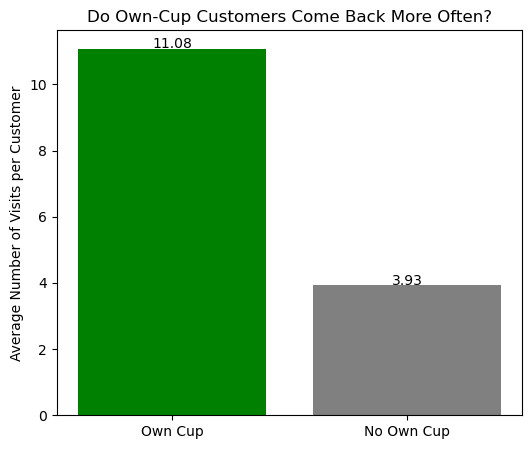

In [63]:
sales["own_cup"] = sales["own_cup"].replace(["N/A", "NaN"], pd.NA).astype("boolean")
sales["customer_id"] = sales["customer_id"].astype(str)

customer_visits = (
    sales.groupby("customer_id")
         .size()
         .reset_index(name="visit_count")
)

owncup_flag = (
    sales.groupby("customer_id")["own_cup"]
         .any()
         .reset_index(name="ever_own_cup")
)

customer_stats = customer_visits.merge(owncup_flag, on="customer_id", how="left")
customer_stats = customer_stats.dropna(subset=["ever_own_cup"])

group_A = customer_stats[customer_stats["ever_own_cup"] == True]
group_B = customer_stats[customer_stats["ever_own_cup"] == False]

avg_A = group_A["visit_count"].mean()
avg_B = group_B["visit_count"].mean()

print("Average visits per customer (Own-Cup Customers):", avg_A)
print("Average visits per customer (Non-Own-Cup Customers):", avg_B)

plt.figure(figsize=(6, 5))
plt.bar(["Own Cup", "No Own Cup"], [avg_A, avg_B], color=["green", "gray"])
plt.ylabel("Average Number of Visits per Customer")
plt.title("Do Own-Cup Customers Come Back More Often?")
plt.text(0, avg_A + 0.02, f"{avg_A:.2f}", ha="center")
plt.text(1, avg_B + 0.02, f"{avg_B:.2f}", ha="center")
plt.show()

Customers who own cup do come back more often than customers who do not own cups. This could show that the cup owners are more loyal or abide by the sustainability goals of the cafe more than the non-cup owners.  

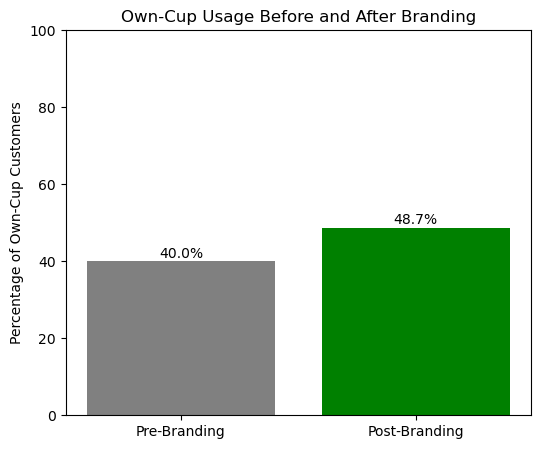

In [64]:
##How many people who bring their own cups before and after branding
import pandas as pd
import matplotlib.pyplot as plt

sales = pd.read_csv("sales.csv")

sales["date"] = pd.to_datetime(sales["date"], errors="coerce")
sales["own_cup"] = sales["own_cup"].replace(["N/A","NaN"], pd.NA).astype("boolean")

pre = sales[(sales["date"] >= "2022-01-01") & (sales["date"] < "2023-11-01")]
post = sales[(sales["date"] >= "2023-11-01") & (sales["date"] <= "2024-12-31")]

pre_pct = pre["own_cup"].mean() * 100
post_pct = post["own_cup"].mean() * 100

plt.figure(figsize=(6,5))
plt.bar(["Pre-Branding", "Post-Branding"], [pre_pct, post_pct], color=["gray","green"])
plt.ylabel("Percentage of Own-Cup Customers")
plt.title("Own-Cup Usage Before and After Branding")
plt.ylim(0,100)
plt.text(0, pre_pct + 1, f"{pre_pct:.1f}%", ha="center")
plt.text(1, post_pct + 1, f"{post_pct:.1f}%", ha="center")
plt.show()


Since there is a significant increase in own cups' usage post-branding, they are accomplishing their mission of sustainability. 